### rd_visualization.ipynb
*Created June 17, 2026* <br/>
This notebook contains some functions for visualizing the solution to a two-component reaction-diffusion PDE.

In [2]:
using CairoMakie, DataFrames, UnPack, Statistics, NBInclude, Random, Printf
#@nbinclude("set_makie_defaults.ipynb")

In [3]:
function plot_profiles(sol; plot_times, overlay = false, size = (400,400), axislabelsize = nothing,
                        ticklabelsize = nothing, titlesize = nothing)
    """
    Plots the solution profiles for the reaction diffusion system 
        u_t = Dᵤ uₓₓ + f(u,v,x,p,t)
        v_t = Dᵥ vₓₓ + g(u,v,x,p,t) 
    at the specified time values. 

    PARAMETERS
    ----------
    sol :: A named tuple containing the following fields: u, v, x, t, p
    plot_times :: A vector of the time values at which to plot the solution
    overlay :: if true, plot u and v together on the same axis for each time value  
    size :: The size of each individual axis 
    """

    u = sol.u
    v = sol.v 
    t = sol.t 
    x = sol.x 
    
    #We'll plot u[n] and v[n] for n ∈ ns_plot 
    ns_plot = unique([argmin(abs.(t .- τ)) for τ in plot_times])

    #Create figure of desired size 
    num_rows = (overlay == true) ? 1 : 2 
    num_cols = length(ns_plot) 
    combined_fig_size = (num_cols * size[1], num_rows * size[2])
    fig = Figure(size = combined_fig_size)

    line_colors = Makie.wong_colors()
    
    for (col, n) in pairs(ns_plot)

        t_current = t[n]
        t_str = @sprintf("%.2f", t_current)
  
        if (overlay == true)
            #Create single axis 
            ax = Axis(fig[1,col], xlabel = L"x", title = L"t = %$(t_str)")
            lines!(ax, x, u[n], label = L"u")
            lines!(ax, x, v[n], label = L"v")
            axislegend(ax, position = :rt)

            if titlesize != nothing
                ax.titlesize = titlesize 
            end

            if axislabelsize != nothing
                ax.xlabelsize = axislabelsize
                ax.ylabelsize = axislabelsize
            end 

            if ticklabelsize != nothing 
                ax.xticklabelsize = ticklabelsize
                ax.yticklabelsize = ticklabelsize
            end 
        
        else
            ax_u = Axis(fig[1,col], xlabel = L"x", title = L"t = %$(t_str)")
            lines!(ax_u, x, u[n], label = L"u", color = line_colors[1])
            axislegend(ax_u, position = :rt)
            
            ax_v = Axis(fig[2,col], xlabel = L"x", title = L"t = %$(t_str)")
            lines!(ax_v, x, v[n], label = L"v", color = line_colors[2])
            axislegend(ax_v, position = :rt)

            if titlesize != nothing
                ax_u.titlesize = titlesize 
                ax_v.titlesize = titlesize 
            end
            
            if axislabelsize != nothing 
                ax_u.xlabelsize = axislabelsize
                ax_u.ylabelsize = axislabelsize
                ax_v.xlabelsize = axislabelsize 
                ax_v.ylabelsize = axislabelsize 
            end 

            if ticklabelsize != nothing 
                ax_u.xticklabelsize = ticklabelsize
                ax_u.yticklabelsize = ticklabelsize 
                ax_v.xticklabelsize = ticklabelsize
                ax_v.yticklabelsize = ticklabelsize 
            end 
            
           
        end 
    end 

    return fig

end 

plot_profiles (generic function with 1 method)

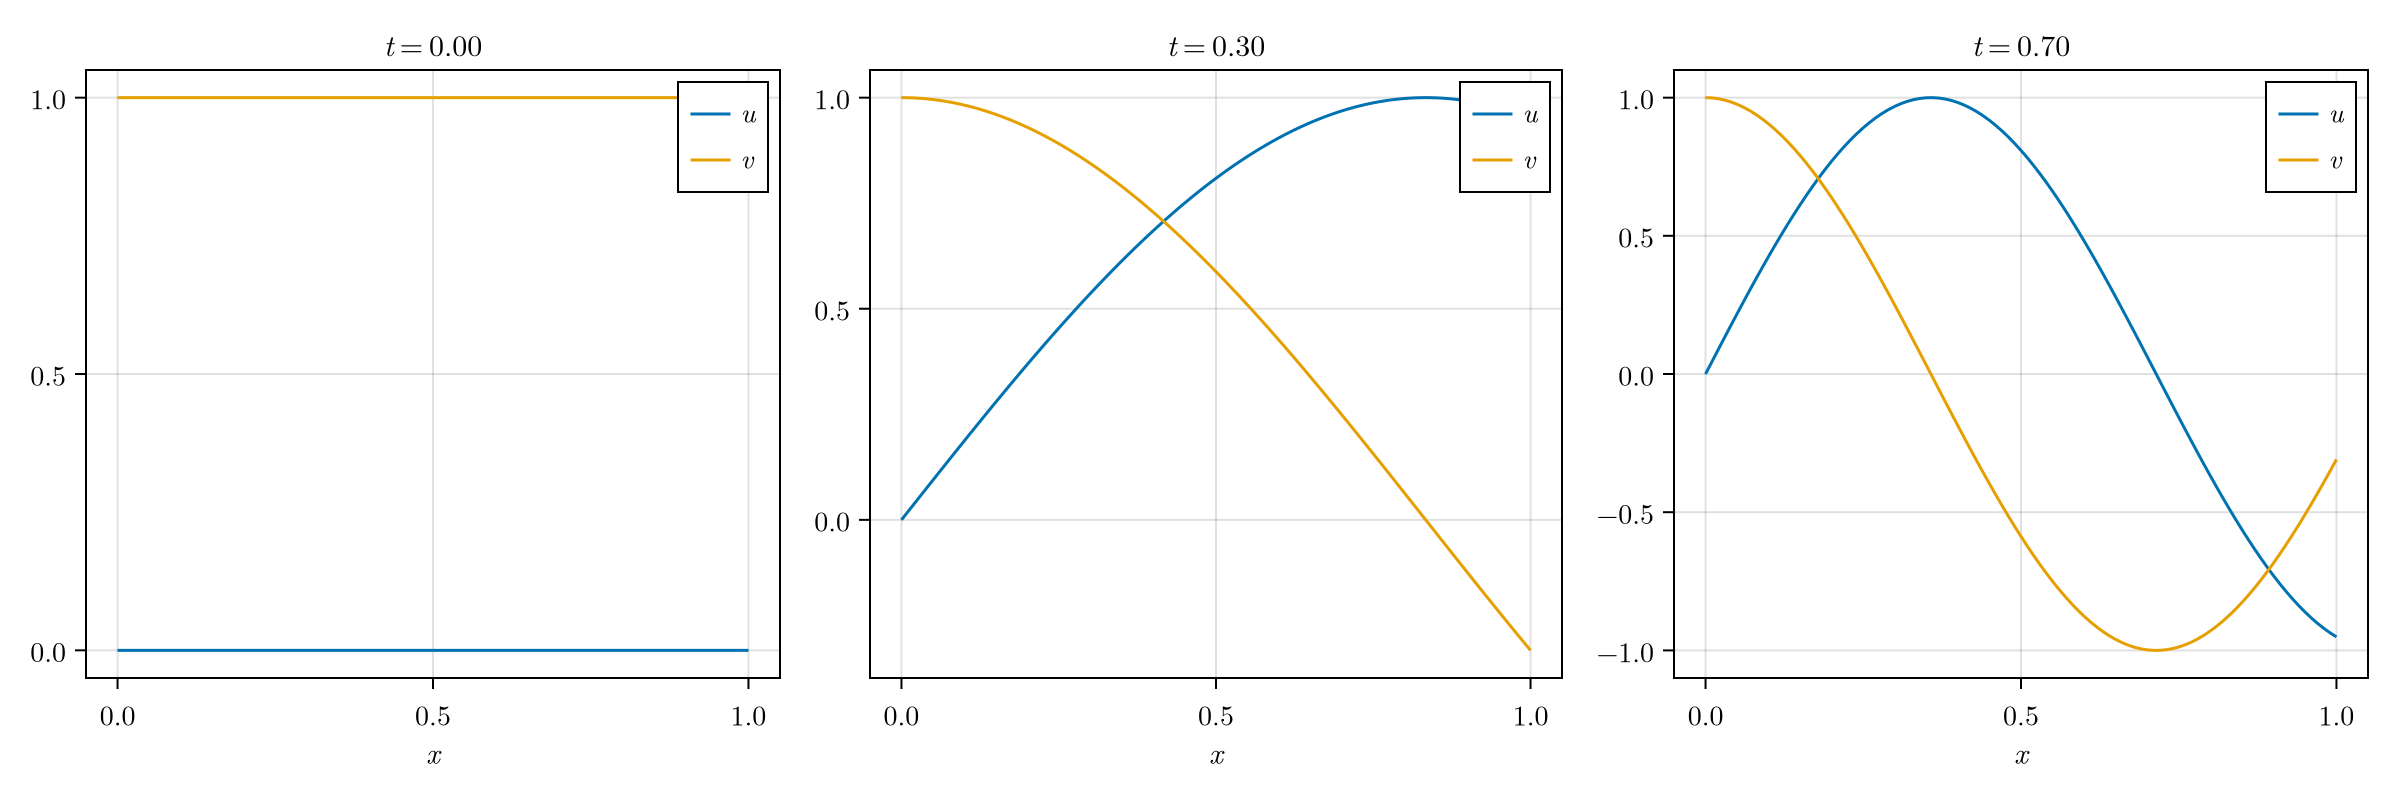

In [161]:
# x = collect(0:0.01:1)
# t = collect(0:0.1:2)
# u = [sin.(2π*tᵢ*x) for tᵢ in t] 
# v = [cos.(2π*tᵢ*x) for tᵢ in t]   
# plot_times = [0.0, 1.0]

# sol = (u = u, v = v, x = x, t = t, p = nothing);
# my_fig = plot_profiles(sol; plot_times = [-100.0, 0.34, 0.7001], overlay = true, axislabelsize = 15, titlesize = 15)

In [ ]:
# function convergence_test(sol, Δts,  )
#     #Solve PDE


    